# CheXNet -> MURA Domain Transfer
## Phase 1 - Environment & Workspace Calibration

Run these cells top-to-bottom at the start of **every** Colab session.
The T4 VM is wiped on disconnect, so Cell 2 re-fetches the repo each time.

Before running: **Runtime -> Change runtime type -> T4 GPU**.

In [2]:
# Cell 1 - Confirm the runtime has the T4 GPU
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [3]:
# Cell 2 - Bootstrap: pull the whole project onto the Colab VM
# Identical for both collaborators. No Google Drive needed - git carries
# the code, the 81 MB weights, and the MURA data.
import os

REPO_URL = "https://github.com/sofiaorlov9821/CheXNet.git"
CHEXNET  = "/content/CheXNet"

if not os.path.exists(CHEXNET):
    !git clone {REPO_URL} {CHEXNET}      # first run of the session
else:
    !cd {CHEXNET} && git pull            # already cloned -> just update

assert os.path.exists(f"{CHEXNET}/model.pth.tar"), "clone failed - check repo access"
print("[OK] Project ready at", CHEXNET)
print(os.listdir(CHEXNET))

Cloning into '/content/CheXNet'...
remote: Enumerating objects: 4244, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 4244 (delta 46), reused 55 (delta 41), pack-reused 4177 (from 1)
Receiving objects: 100% (4244/4244), 276.04 MiB | 30.75 MiB/s, done.
Resolving deltas: 100% (47/47), done.
Updating files: 100% (2140/2140), done.
[OK] Project ready at /content/CheXNet
['model.pth.tar', '.git', 'model.py', 'localization', 'MURA_MSK_Xrays_files', 'read_data.py', 'ChestX-ray14', 'final_p.ipynb', '.gitignore', 'README.md', '.gitattributes']


In [4]:
# Cell 3 - Inspect the CheXNet checkpoint (model.pth.tar)
import torch

ckpt = torch.load(f"{CHEXNET}/model.pth.tar", map_location="cpu")

# A checkpoint is a dict: the weights ('state_dict') plus training bookkeeping.
print("Top-level keys:", list(ckpt.keys()))
print("epoch:", ckpt.get("epoch"), "| best_loss:", ckpt.get("best_loss"))

sd = ckpt["state_dict"]
print("\nNumber of weight tensors:", len(sd))

print("\nFirst 8 layers (name + shape):")
for k, v in list(sd.items())[:8]:
    print(f"  {k:55s} {tuple(v.shape)}")

print("\nOriginal 14-class classifier head:")
for k, v in sd.items():
    if "classifier" in k:
        print(f"  {k:55s} {tuple(v.shape)}")

Top-level keys: ['optimizer', 'epoch', 'arch', 'state_dict']
epoch: 14 | best_loss: None

Number of weight tensors: 606

First 8 layers (name + shape):
  module.densenet121.features.conv0.weight                (64, 3, 7, 7)
  module.densenet121.features.norm0.weight                (64,)
  module.densenet121.features.norm0.bias                  (64,)
  module.densenet121.features.norm0.running_mean          (64,)
  module.densenet121.features.norm0.running_var           (64,)
  module.densenet121.features.denseblock1.denselayer1.norm.1.weight (64,)
  module.densenet121.features.denseblock1.denselayer1.norm.1.bias (64,)
  module.densenet121.features.denseblock1.denselayer1.norm.1.running_mean (64,)

Original 14-class classifier head:
  module.densenet121.classifier.0.weight                  (14, 1024)
  module.densenet121.classifier.0.bias                    (14,)


In [5]:
# Cell 4 - Make CheXNet importable and load the model class
import sys
if CHEXNET not in sys.path:
    sys.path.append(CHEXNET)             # append = won't shadow torch

from model import DenseNet121            # gets the class; does NOT run main()
MURA_DIR = f"{CHEXNET}/MURA_MSK_Xrays_files"
assert os.path.isdir(MURA_DIR), "MURA folder not found"
print("[OK] Imported DenseNet121")
print("[OK] MURA data at", MURA_DIR)

[OK] Imported DenseNet121
[OK] MURA data at /content/CheXNet/MURA_MSK_Xrays_files


In [6]:
# Cell 5 - Confirm the GPU is live (final Phase 1 check)
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE")
assert DEVICE.type == "cuda", "No GPU - Runtime > Change runtime type > T4 GPU"

Device: cuda
GPU: Tesla T4


---
## Phase 2 - Preprocessing & MURA Subset Loading

Body part: **XR_FOREARM** (the subset in this repo).  
Labels come from the study-folder name: `..._positive` -> **1 (abnormal)**, `..._negative` -> **0 (normal)**.

Pipeline: `SquarePad` (no distortion) -> `Resize(224)` -> spatial augmentations (train only) -> ImageNet normalization.

In [7]:
# Cell 6 - Imports + SquarePad + transforms
import os
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


class SquarePad:
    """Pad a PIL image to a square (side = longer edge) BEFORE resizing.

    Resizing a non-square X-ray straight to 224x224 stretches the anatomy.
    Padding to a square first preserves the aspect ratio so bones keep their
    true proportions. Padding is symmetric and filled with 0 (black), which
    matches the typical dark radiograph background.
    """
    def __call__(self, image):
        w, h = image.size
        s = max(w, h)
        left = (s - w) // 2
        top  = (s - h) // 2
        right = s - w - left
        bottom = s - h - top
        return TF.pad(image, (left, top, right, bottom), fill=0)


# Train: augment for spatial invariance. Eval: deterministic, no augmentation.
train_tf = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print('[OK] SquarePad + transforms defined')

[OK] SquarePad + transforms defined


In [8]:
# Cell 7 - MURA Dataset
class MURADataset(Dataset):
    """MURA musculoskeletal radiographs as a binary image classifier dataset.

    Directory layout:
        <root>/<split>/<body_part>/patientXXXXX/studyN_positive|negative/imageN.png

    The label is parsed from the study-folder name ('positive' -> 1 abnormal,
    'negative' -> 0 normal). Each PNG is treated as one independent sample
    (per-image classification), which is standard for a proof-of-concept.

    Args:
        root:      path to MURA_MSK_Xrays_files
        body_part: e.g. 'XR_FOREARM'
        split:     'train' or 'valid'
        transform: torchvision transform applied to each PIL image
    """
    def __init__(self, root, body_part='XR_FOREARM', split='train', transform=None):
        self.transform = transform
        self.samples = []  # (image_path, label)
        base = os.path.join(root, split, body_part)
        for patient in sorted(os.listdir(base)):
            pdir = os.path.join(base, patient)
            if not os.path.isdir(pdir):
                continue
            for study in sorted(os.listdir(pdir)):
                sdir = os.path.join(pdir, study)
                if not os.path.isdir(sdir):
                    continue
                label = 1 if 'positive' in study.lower() else 0
                for fname in sorted(os.listdir(sdir)):
                    if fname.lower().endswith('.png'):   # skip .DS_Store etc.
                        self.samples.append((os.path.join(sdir, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')   # 1-ch X-ray -> 3-ch for DenseNet
        if self.transform is not None:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)
print('[OK] MURADataset defined')

[OK] MURADataset defined


In [9]:
# Cell 8 - Build datasets, dataloaders, and report class balance
BATCH_SIZE = 32   # comfortable on a T4 at 224x224
BODY_PART  = 'XR_FOREARM'

train_ds = MURADataset(MURA_DIR, BODY_PART, 'train', train_tf)
valid_ds = MURADataset(MURA_DIR, BODY_PART, 'valid', eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Class balance (MURA is imbalanced - we'll use this for pos_weight later)
def counts(ds):
    pos = sum(l for _, l in ds.samples)
    return len(ds), int(pos), len(ds) - int(pos)

n_tr, pos_tr, neg_tr = counts(train_ds)
n_va, pos_va, neg_va = counts(valid_ds)
print(f'TRAIN: {n_tr} imgs | abnormal {pos_tr} / normal {neg_tr}')
print(f'VALID: {n_va} imgs | abnormal {pos_va} / normal {neg_va}')
pos_weight = torch.tensor([neg_tr / max(pos_tr, 1)])   # save for Phase 3 loss
print(f'pos_weight (neg/pos) = {pos_weight.item():.3f}')

TRAIN: 1825 imgs | abnormal 661 / normal 1164
VALID: 301 imgs | abnormal 151 / normal 150
pos_weight (neg/pos) = 1.761


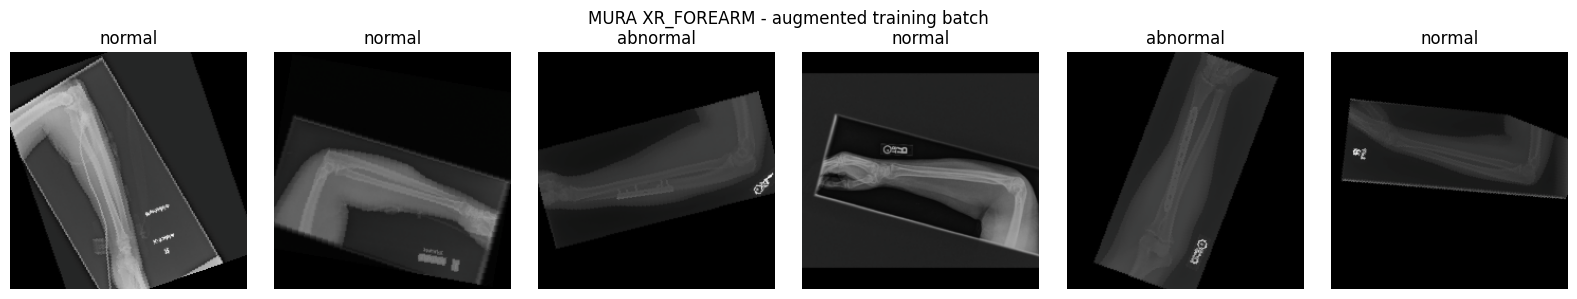

Batch tensor: torch.Size([32, 3, 224, 224])


In [10]:
# Cell 9 - Sanity check: visualise one augmented batch
import matplotlib.pyplot as plt
import numpy as np

mean = np.array(IMAGENET_MEAN); std = np.array(IMAGENET_STD)
imgs, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i, ax in enumerate(axes):
    img = imgs[i].permute(1, 2, 0).numpy() * std + mean   # un-normalize
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title('abnormal' if labels[i] == 1 else 'normal')
    ax.axis('off')
plt.suptitle('MURA XR_FOREARM - augmented training batch')
plt.tight_layout(); plt.show()
print('Batch tensor:', imgs.shape)   # expect [32, 3, 224, 224]

---
## Phase 3 - Experiment 1: Frozen CheXNet Backbone

Load CheXNet's pretrained DenseNet-121, **freeze the whole backbone**, and train **only a new 1-node classifier** on MURA.
This measures how useful CheXNet's chest-xray features are *as-is* for bone abnormality detection.

Metrics on the validation set: **AUC-ROC, F1, Precision, Recall**.

In [11]:
# Cell 10 - Robust CheXNet weight loader
import re
import torch
import torch.nn as nn

CKPT_PATH = f"{CHEXNET}/model.pth.tar"

def load_chexnet_backbone(ckpt_path, device):
    """Load arnoweng CheXNet weights into a DenseNet121(14) model.

    Fixes the three quirks of the released checkpoint (all confirmed for this file):
      1. Weights live under checkpoint['state_dict'].
      2. Keys carry a 'module.' prefix (saved wrapped in DataParallel).
      3. Keys use OLD torchvision DenseNet naming ('norm.1' -> 'norm1').
    Returns the model with its original 14-class head still matching the ckpt.
    """
    model = DenseNet121(14)                        # same head as when ckpt was saved
    checkpoint = torch.load(ckpt_path, map_location='cpu')   # safe single-GPU load
    state_dict = checkpoint['state_dict']

    # old-torchvision denselayer fix: '...norm.1.weight' -> '...norm1.weight'
    pattern = re.compile(
        r'^(.*denselayer\d+\.(?:norm|relu|conv))\.'
        r'((?:[12])\.(?:weight|bias|running_mean|running_var))$')

    fixed = {}
    for key, val in state_dict.items():
        k = key[len('module.'):] if key.startswith('module.') else key
        m = pattern.match(k)
        if m:
            k = m.group(1) + m.group(2)            # merge 'norm.1' -> 'norm1'
        fixed[k] = val

    missing, unexpected = model.load_state_dict(fixed, strict=False)
    print(f'[OK] CheXNet weights loaded | missing={len(missing)} unexpected={len(unexpected)}')
    return model.to(device)

In [12]:
# Cell 11 - Build the FROZEN model (Experiment 1)
def build_frozen_model(ckpt_path, device):
    """CheXNet backbone frozen; only a fresh 1-logit classifier is trainable."""
    model = load_chexnet_backbone(ckpt_path, device)

    for p in model.parameters():          # freeze EVERYTHING
        p.requires_grad = False

    # Replace the 14-way Sigmoid head with a single logit (no Sigmoid:
    # BCEWithLogitsLoss applies it internally). New layer is trainable by default.
    num_ftrs = model.densenet121.classifier[0].in_features
    model.densenet121.classifier = nn.Linear(num_ftrs, 1).to(device)

    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f'Trainable params: {n_train:,} / {n_total:,}  (only the classifier head)')
    return model

In [13]:
# Cell 12 - Loss, training loop, and evaluation (reused by all 3 experiments)
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))  # pos_weight from Phase 2

def train_one_epoch(model, loader, optimizer, device):
    """One pass over the training data. Returns mean loss."""
    model.train()
    running = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)          # [B]
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running += loss.item() * imgs.size(0)
    return running / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, device):
    """Validation metrics at threshold 0.5: AUC, F1, Precision, Recall."""
    model.eval()
    probs_all, labels_all = [], []
    for imgs, labels in loader:
        logits = model(imgs.to(device)).squeeze(1)
        probs_all.append(torch.sigmoid(logits).cpu())
        labels_all.append(labels)
    probs = torch.cat(probs_all).numpy()
    labels = torch.cat(labels_all).numpy()
    preds = (probs >= 0.5).astype(int)
    return {'AUC': roc_auc_score(labels, probs),
            'F1': f1_score(labels, preds, zero_division=0),
            'Precision': precision_score(labels, preds, zero_division=0),
            'Recall': recall_score(labels, preds, zero_division=0)}

In [14]:
# Cell 13 - Train Experiment 1 (Frozen CheXNet)
torch.manual_seed(42)

exp1_model = build_frozen_model(CKPT_PATH, DEVICE)

# Adam over ONLY the trainable (classifier) params. Higher LR is fine - it's just a linear head.
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, exp1_model.parameters()), lr=1e-3)

EPOCHS = 10
for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(exp1_model, train_loader, optimizer, DEVICE)
    m = evaluate(exp1_model, valid_loader, DEVICE)
    print(f"Epoch {epoch:02d} | loss {loss:.4f} | "
          f"AUC {m['AUC']:.3f}  F1 {m['F1']:.3f}  P {m['Precision']:.3f}  R {m['Recall']:.3f}")

exp1_metrics = evaluate(exp1_model, valid_loader, DEVICE)
print('\n[Experiment 1 - Frozen CheXNet] final:', {k: round(v,3) for k,v in exp1_metrics.items()})
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 119MB/s] 


[OK] CheXNet weights loaded | missing=0 unexpected=0
Trainable params: 1,025 / 6,954,881  (only the classifier head)
Epoch 01 | loss 0.8884 | AUC 0.580  F1 0.667  P 0.507  R 0.974
Epoch 02 | loss 0.8766 | AUC 0.591  F1 0.533  P 0.593  R 0.483
Epoch 03 | loss 0.8530 | AUC 0.604  F1 0.593  P 0.583  R 0.603
Epoch 04 | loss 0.8481 | AUC 0.612  F1 0.621  P 0.545  R 0.722
Epoch 05 | loss 0.8449 | AUC 0.612  F1 0.631  P 0.549  R 0.742
Epoch 06 | loss 0.8456 | AUC 0.610  F1 0.583  P 0.583  R 0.583
Epoch 07 | loss 0.8427 | AUC 0.596  F1 0.639  P 0.547  R 0.768
Epoch 08 | loss 0.8462 | AUC 0.609  F1 0.598  P 0.600  R 0.596
Epoch 09 | loss 0.8380 | AUC 0.613  F1 0.637  P 0.571  R 0.722
Epoch 10 | loss 0.8573 | AUC 0.606  F1 0.597  P 0.605  R 0.589

[Experiment 1 - Frozen CheXNet] final: {'AUC': np.float64(0.606), 'F1': 0.597, 'Precision': 0.605, 'Recall': 0.589}


In [ ]:
# Cell 14 - Preview the model architecture
# Run AFTER Cell 13 (needs exp1_model). Shows the swapped head + frozen/trainable split.
try:
    from torchinfo import summary
except ImportError:
    %pip install torchinfo -q
    from torchinfo import summary

model = exp1_model  # the frozen-backbone Experiment-1 model

# 1) The classifier head we swapped in (14-way Sigmoid -> single logit)
print('Classifier head:', model.densenet121.classifier)

# 2) Frozen vs trainable parameter split
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f'Trainable: {n_train:,}  |  Frozen: {n_total - n_train:,}  |  Total: {n_total:,}')

# 3) Layer-by-layer summary (input = 1 image, 3x224x224). 'Param #' column
#    shows sizes; the Trainable column shows what the freeze actually did.
summary(model, input_size=(1, 3, 224, 224),
        col_names=('output_size', 'num_params', 'trainable'),
        depth=2)

Classifier head: Linear(in_features=1024, out_features=1, bias=True)
Trainable: 1,025  |  Frozen: 6,953,856  |  Total: 6,954,881


Layer (type:depth-idx)                        Output Shape              Param #                   Trainable
DenseNet121                                   [1, 1]                    --                        Partial
├─DenseNet: 1-1                               [1, 1]                    --                        Partial
│    └─Sequential: 2-1                        [1, 1024, 7, 7]           (6,953,856)               False
│    └─Linear: 2-2                            [1, 1]                    1,025                     True
Total params: 6,954,881
Trainable params: 1,025
Non-trainable params: 6,953,856
Total mult-adds (Units.GIGABYTES): 2.83
Input size (MB): 0.60
Forward/backward pass size (MB): 180.53
Params size (MB): 27.82
Estimated Total Size (MB): 208.95

---
## Phase 4 - Experiment 2: Fine-Tuned CheXNet Backbone
Load CheXNet's pretrained DenseNet-121, unfreeze all layers, and train the entire network end-to-end on MURA using a lower learning rate ($10^{-4}$).This evaluates whether fine-tuning allows CheXNet's chest-X-ray feature representations to adapt effectively to a novel anatomical domain (bone radiographs).

Metrics on the validation set: AUC-ROC, F1, Precision, Recall.

In [16]:
# Cell 15 - Experiment 2: Fine-Tuned CheXNet (End-to-End Training)
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

def build_finetuned_model(ckpt_path, device):
    """Loads CheXNet weights and keeps ALL layers UNFROZEN for End-to-End Fine-Tuning."""
    # 1. Load CheXNet with 14-class head and fix legacy weight keys
    model = load_chexnet_backbone(ckpt_path, device)
    
    # 2. Keep all parameters TRAINABLE (unfreeze backbone)
    for p in model.parameters():
        p.requires_grad = True

    # 3. Swap classifier head to 1 output for MURA binary classification
    num_ftrs = model.densenet121.classifier[0].in_features
    model.densenet121.classifier = nn.Linear(num_ftrs, 1).to(device)

    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f'[OK] Model built for Exp 2 | Trainable: {n_train:,} / {n_total:,} (ALL layers unfrozen)')
    return model

# Initialize Experiment 2 Model
exp2_model = build_finetuned_model(CKPT_PATH, DEVICE)

# Lower learning rate (1e-4) for fine-tuning to protect pre-trained weights
optimizer2 = optim.Adam(exp2_model.parameters(), lr=1e-4)

EPOCHS = 10
print(f"\n--- Starting Experiment 2: Fine-Tuning CheXNet ({EPOCHS} Epochs) ---")

best_auc2 = 0.0
best_metrics = {} 

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(exp2_model, train_loader, optimizer2, DEVICE)
    m = evaluate(exp2_model, valid_loader, DEVICE)
    print(f"Epoch {epoch:02d} | loss {loss:.4f} | "
          f"AUC {m['AUC']:.3f}  F1 {m['F1']:.3f}  P {m['Precision']:.3f}  R {m['Recall']:.3f}")

    if m['AUC'] > best_auc2:
        best_auc2 = m['AUC']
        best_metrics = m
        torch.save(exp2_model.state_dict(), "exp2_finetuned_chexnet.pth")


exp2_model.load_state_dict(torch.load("exp2_finetuned_chexnet.pth"))
print('\n[Experiment 2 - Fine-Tuned CheXNet] BEST final metrics:', {k: round(v, 3) for k, v in best_metrics.items()})

torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[OK] CheXNet weights loaded | missing=0 unexpected=0
[OK] Model built for Exp 2 | Trainable: 6,954,881 / 6,954,881 (ALL layers unfrozen)

--- Starting Experiment 2: Fine-Tuning CheXNet (10 Epochs) ---
Epoch 01 | loss 0.8672 | AUC 0.658  F1 0.619  P 0.586  R 0.656
Epoch 02 | loss 0.7972 | AUC 0.726  F1 0.648  P 0.692  R 0.609
Epoch 03 | loss 0.6978 | AUC 0.800  F1 0.716  P 0.731  R 0.702
Epoch 04 | loss 0.6420 | AUC 0.802  F1 0.706  P 0.805  R 0.629
Epoch 05 | loss 0.5976 | AUC 0.831  F1 0.714  P 0.814  R 0.636
Epoch 06 | loss 0.5764 | AUC 0.833  F1 0.740  P 0.913  R 0.623
Epoch 07 | loss 0.5616 | AUC 0.840  F1 0.758  P 0.782  R 0.735
Epoch 08 | loss 0.5441 | AUC 0.865  F1 0.774  P 0.896  R 0.682
Epoch 09 | loss 0.5204 | AUC 0.861  F1 0.742  P 0.948  R 0.609
Epoch 10 | loss 0.5292 | AUC 0.849  F1 0.754  P 0.767  R 0.742

[Experiment 2 - Fine-Tuned CheXNet] BEST final metrics: {'AUC': np.float64(0.865), 'F1': 0.774, 'Precision': 0.896, 'Recall': 0.682}


In [ ]:
# Cell 16 - Preview the Fine-Tuned Model Architecture (Experiment 2)
# Run AFTER Cell 15. Shows that ALL 6.95M parameters are now TRAINABLE.
try:
    from torchinfo import summary
except ImportError:
    %pip install torchinfo -q
    from torchinfo import summary

# 1) Use the Fine-Tuned model from Experiment 2
model_exp2 = exp2_model

print('--- Experiment 2 Model Summary ---')
print('Classifier head:', model_exp2.densenet121.classifier)

# 2) Calculate trainable vs frozen parameters
n_train = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model_exp2.parameters())
print(f'Trainable params: {n_train:,}  |  Frozen params: {n_total - n_train:,}  |  Total: {n_total:,}')

# 3) Generate layer-by-layer summary
summary(model_exp2, input_size=(1, 3, 224, 224),
        col_names=('output_size', 'num_params', 'trainable'),
        depth=2)

--- Experiment 2 Model Summary ---
Classifier head: Linear(in_features=1024, out_features=1, bias=True)
Trainable params: 6,954,881  |  Frozen params: 0  |  Total: 6,954,881


Layer (type:depth-idx)                        Output Shape              Param #                   Trainable
DenseNet121                                   [1, 1]                    --                        True
├─DenseNet: 1-1                               [1, 1]                    --                        True
│    └─Sequential: 2-1                        [1, 1024, 7, 7]           6,953,856                 True
│    └─Linear: 2-2                            [1, 1]                    1,025                     True
Total params: 6,954,881
Trainable params: 6,954,881
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 2.83
Input size (MB): 0.60
Forward/backward pass size (MB): 180.53
Params size (MB): 27.82
Estimated Total Size (MB): 208.95

---
## Phase 5 - Experiment 3: DenseNet-121 Trained From Scratch (Control Baseline)
Initialize a fresh DenseNet-121 architecture with random weights (no ImageNet or CheXNet pretraining) and train the entire network end-to-end on MURA using a standard learning rate ($10^{-3}$).
This serves as the essential control group to isolate and prove the exact value of CheXNet's chest-X-ray pretraining when transferring to a novel anatomical domain (bone radiographs).  

Metrics on the validation set: AUC-ROC, F1, Precision, Recall. 

In [18]:
# Cell 17 - Experiment 3: DenseNet-121 Trained From Scratch (Control Group)
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import densenet121

torch.manual_seed(42)

def build_scratch_model(device):
    """Initializes a fresh DenseNet-121 architecture with RANDOM weights (No Pretraining).
    
    This serves as the control baseline to isolate and prove the exact value of 
    CheXNet's chest-X-ray pretraining when transferring to bone radiographs (MURA).
    """
    # 1. Load DenseNet-121 architecture with weights=None (Random Initialization)
    model = densenet121(weights=None)
    
    # 2. Replace the 1000-class ImageNet head with a 1-output Linear layer for MURA
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Linear(num_ftrs, 1)
    
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'[OK] Model built for Exp 3 (Scratch) | Trainable params: {n_train:,} (ALL random weights)')
    return model.to(device)

# 1. Build Scratch Model
exp3_model = build_scratch_model(DEVICE)

# 2. Optimizer: Train ALL parameters. Higher LR (1e-3) is standard for scratch training
optimizer3 = optim.Adam(exp3_model.parameters(), lr=1e-3)

EPOCHS = 10
print(f"\n--- Starting Experiment 3: DenseNet-121 From Scratch ({EPOCHS} Epochs) ---")

best_auc3 = 0.0
best_metrics3 = {}

# 3. Training Loop + Best Model Checkpoint
for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(exp3_model, train_loader, optimizer3, DEVICE)
    m = evaluate(exp3_model, valid_loader, DEVICE)
    
    print(f"Epoch {epoch:02d} | loss {loss:.4f} | "
          f"AUC {m['AUC']:.3f}  F1 {m['F1']:.3f}  P {m['Precision']:.3f}  R {m['Recall']:.3f}")

    if m['AUC'] > best_auc3:
        best_auc3 = m['AUC']
        best_metrics3 = m
        torch.save(exp3_model.state_dict(), "exp3_scratch_densenet.pth")

# 4. Load Best Model Checkpoint for Final Evaluation
exp3_model.load_state_dict(torch.load("exp3_scratch_densenet.pth"))
print('\n[Experiment 3 - From Scratch Baseline] BEST final metrics:', {k: round(v, 3) for k, v in best_metrics3.items()})

torch.cuda.empty_cache()

[OK] Model built for Exp 3 (Scratch) | Trainable params: 6,954,881 (ALL random weights)

--- Starting Experiment 3: DenseNet-121 From Scratch (10 Epochs) ---
Epoch 01 | loss 0.9209 | AUC 0.634  F1 0.383  P 0.651  R 0.272
Epoch 02 | loss 0.8691 | AUC 0.586  F1 0.337  P 0.733  R 0.219
Epoch 03 | loss 0.8670 | AUC 0.692  F1 0.622  P 0.602  R 0.642
Epoch 04 | loss 0.8643 | AUC 0.597  F1 0.654  P 0.505  R 0.927
Epoch 05 | loss 0.8793 | AUC 0.569  F1 0.258  P 0.686  R 0.159
Epoch 06 | loss 0.8683 | AUC 0.590  F1 0.000  P 0.000  R 0.000
Epoch 07 | loss 0.8802 | AUC 0.554  F1 0.455  P 0.589  R 0.371
Epoch 08 | loss 0.8510 | AUC 0.660  F1 0.585  P 0.643  R 0.536
Epoch 09 | loss 0.8390 | AUC 0.643  F1 0.623  P 0.588  R 0.662
Epoch 10 | loss 0.8381 | AUC 0.620  F1 0.668  P 0.538  R 0.881

[Experiment 3 - From Scratch Baseline] BEST final metrics: {'AUC': np.float64(0.692), 'F1': 0.622, 'Precision': 0.602, 'Recall': 0.642}


In [ ]:
# Cell 18 - Preview the Scratch Model Architecture (Experiment 3)
# Run AFTER Cell 17 (needs exp3_model). Shows full architecture initialized from scratch.
try:
    from torchinfo import summary
except ImportError:
    %pip install torchinfo -q
    from torchinfo import summary

model_exp3 = exp3_model  # The from-scratch DenseNet-121 model from Exp 3

print('--- Experiment 3 Model Summary (Trained From Scratch) ---')
print('Classifier head:', model_exp3.classifier)

# Calculate trainable vs frozen parameters
n_train = sum(p.numel() for p in model_exp3.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model_exp3.parameters())
print(f'Trainable params: {n_train:,}  |  Frozen params: {n_total - n_train:,}  |  Total: {n_total:,}')

# Generate layer-by-layer summary
summary(model_exp3, input_size=(1, 3, 224, 224),
        col_names=('output_size', 'num_params', 'trainable'),
        depth=2)

--- Experiment 3 Model Summary (Trained From Scratch) ---
Classifier head: Linear(in_features=1024, out_features=1, bias=True)
Trainable params: 6,954,881  |  Frozen params: 0  |  Total: 6,954,881


Layer (type:depth-idx)                   Output Shape              Param #                   Trainable
DenseNet                                 [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 1024, 7, 7]           --                        True
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408                     True
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128                       True
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --                        --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --                        --
│    └─_DenseBlock: 2-5                  [1, 256, 56, 56]          335,040                   True
│    └─_Transition: 2-6                  [1, 128, 28, 28]          33,280                    True
│    └─_DenseBlock: 2-7                  [1, 512, 28, 28]          919,680                   True
│    └─_Transition:

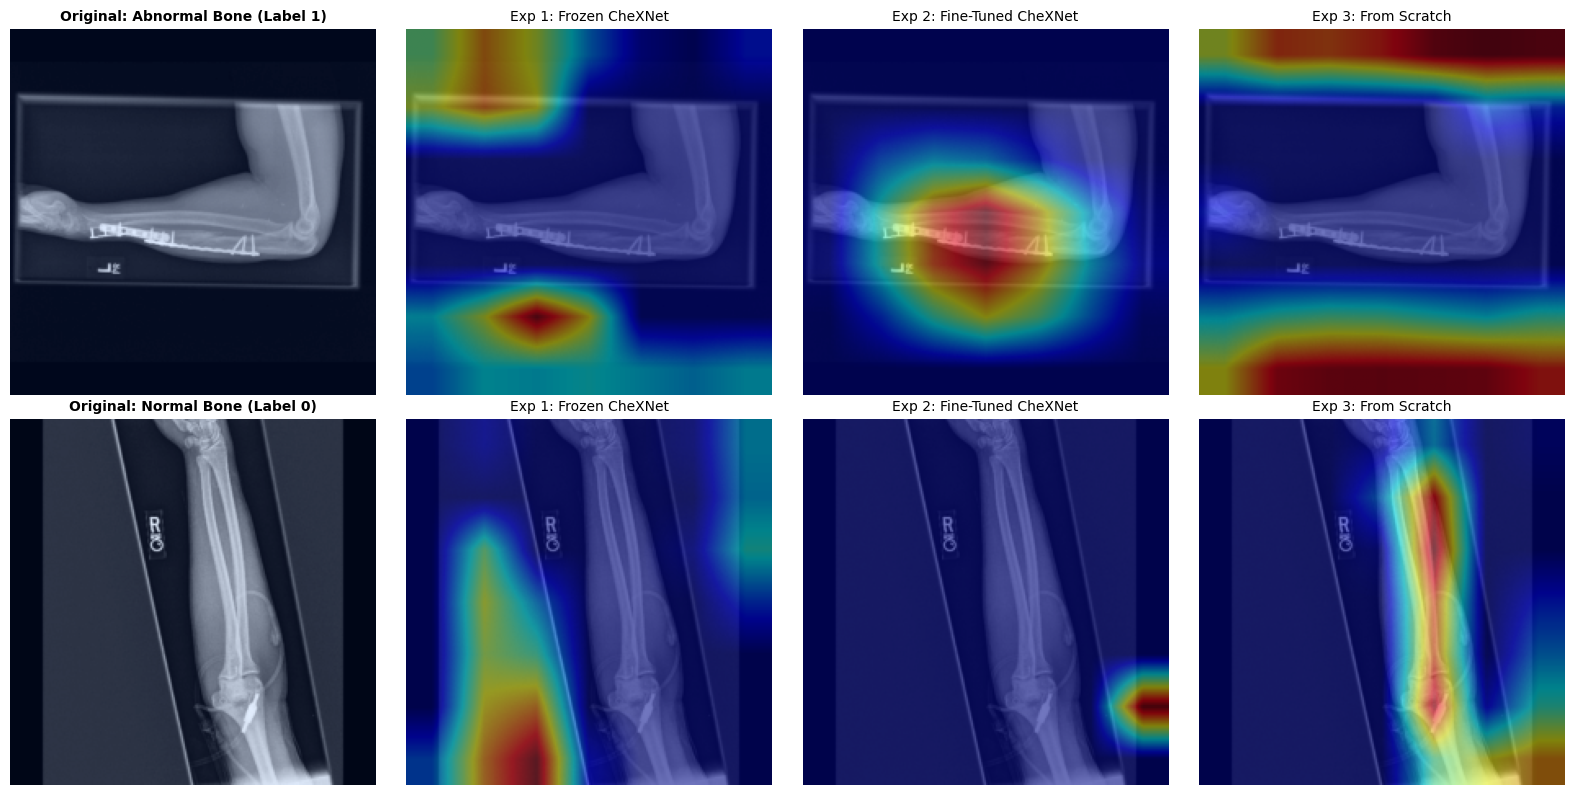

[OK] Safe PyTorch Grad-CAM visualization grid generated and saved successfully!


In [26]:
# Cell 19 - Interpretability via Native PyTorch Grad-CAM Across All 3 Experiments (FIXED)
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt

def compute_safe_gradcam(model, img_tensor, is_chexnet_model=True):
    """
    Computes Grad-CAM heatmaps safely for DenseNet-121 without encountering inplace/view Autograd errors.
    Directly attaches a gradient hook to the target feature tensor output.
    """
    # Ensure model is in eval mode and gradients are enabled
    model.eval()
    
    # 1. Isolate the target feature extractor block (densenet121.features or features)
    if is_chexnet_model:
        feature_extractor = model.densenet121.features
    else:
        feature_extractor = model.features

    # Variables to hold captured activation map and its backpropagated gradient
    feature_conv_output = None
    feature_conv_grad = None

    def save_gradient(grad):
        nonlocal feature_conv_grad
        feature_conv_grad = grad

    # 2. Forward pass up to the feature map
    img_tensor = img_tensor.clone().detach().requires_grad_(True)
    
    # Forward through feature extractor
    features = feature_extractor(img_tensor)
    
    # Register hook directly on the feature Tensor to avoid Module BackwardHook issues
    features.register_hook(save_gradient)
    feature_conv_output = features

    # 3. Forward pass through the rest of the network (Pooling + Classifier)
    out = F.relu(features, inplace=False)
    out = F.adaptive_avg_pool2d(out, (1, 1))
    out = torch.flatten(out, 1)
    
    if is_chexnet_model:
        logits = model.densenet121.classifier(out)
    else:
        logits = model.classifier(out)

    # 4. Backward pass on the positive class logit
    score = logits[0, 0]
    model.zero_grad()
    score.backward()

    # 5. Extract numpy arrays for activations and gradients
    act = feature_conv_output.detach().cpu().numpy()[0]   # Shape: [1024, 7, 7]
    grad = feature_conv_grad.detach().cpu().numpy()[0]    # Shape: [1024, 7, 7]

    # 6. Compute CAM: GAP over gradients -> Weight activations -> ReLU
    weights = np.mean(grad, axis=(1, 2))                  # Shape: [1024]
    cam = np.zeros(act.shape[1:], dtype=np.float32)       # Shape: [7, 7]

    for i, w in enumerate(weights):
        cam += w * act[i]

    cam = np.maximum(cam, 0)                               # Apply ReLU
    if cam.max() > 0:
        cam = cam / cam.max()                              # Normalize to [0, 1]

    # Resize heatmap to input image size (224, 224)
    cam_resized = cv2.resize(cam, (img_tensor.shape[3], img_tensor.shape[2]))
    return cam_resized

def overlay_heatmap(img_np, heatmap):
    """Overlays the Grad-CAM heatmap on top of the original normalized RGB image."""
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.5 * heatmap_color + 0.5 * img_np
    return np.clip(overlay, 0, 1)

# --- 1. Select two representative validation samples (Abnormal vs Normal) ---
abnormal_sample, normal_sample = None, None

for imgs, labels in valid_loader:
    for i in range(len(labels)):
        if labels[i].item() == 1.0 and abnormal_sample is None:
            abnormal_sample = (imgs[i:i+1], labels[i].item())
        elif labels[i].item() == 0.0 and normal_sample is None:
            normal_sample = (imgs[i:i+1], labels[i].item())
    if abnormal_sample is not None and normal_sample is not None:
        break

samples_to_show = [("Abnormal Bone (Label 1)", abnormal_sample), ("Normal Bone (Label 0)", normal_sample)]

models_dict = {
    "Exp 1: Frozen CheXNet": (exp1_model, True),
    "Exp 2: Fine-Tuned CheXNet": (exp2_model, True),
    "Exp 3: From Scratch": (exp3_model, False)
}

# --- 2. Plot Visualizations Comparison Grid ---
fig, axes = plt.subplots(len(samples_to_show), 4, figsize=(16, 8))

for row_idx, (title_str, (img_tensor, label_val)) in enumerate(samples_to_show):
    # Normalize original image tensor for plotting [H, W, C] in range [0, 1]
    img_np = img_tensor[0].cpu().numpy().transpose(1, 2, 0)
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    
    # Column 0: Original Image
    axes[row_idx, 0].imshow(img_np)
    axes[row_idx, 0].set_title(f"Original: {title_str}", fontsize=10, fontweight='bold')
    axes[row_idx, 0].axis('off')
    
    # Columns 1-3: Grad-CAM Overlay for each experiment
    for col_idx, (exp_name, (model_obj, is_chexnet)) in enumerate(models_dict.items(), start=1):
        heatmap = compute_safe_gradcam(model_obj, img_tensor.to(DEVICE), is_chexnet_model=is_chexnet)
        cam_overlay = overlay_heatmap(img_np, heatmap)
        
        axes[row_idx, col_idx].imshow(cam_overlay)
        axes[row_idx, col_idx].set_title(exp_name, fontsize=10)
        axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.savefig("gradcam_experiments_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Safe PyTorch Grad-CAM visualization grid generated and saved successfully!")